# AI Task Automation Evaluator

## Exploratory Data Analysis (EDA)

This notebook analyzes the datasets related to AI automation capability and task evaluation.

#### Import thư viện

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Hiển thị biểu đồ trong notebook
%matplotlib inline

#### Đọc dữ liệu 

In [2]:
metadata = pd.read_csv("../data/domain_worker_metadata.csv")

desires = pd.read_csv("../data/domain_worker_desires.csv")

tasks = pd.read_csv("../data/task_statement_with_metadata.csv")

expert = pd.read_csv("../data/expert_rated_technological_capability.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


#### Kiểm tra kích thước dữ liệu

In [3]:
print("Metadata:", metadata.shape)
print("Desires :", desires.shape)
print("Tasks   :", tasks.shape)
print("Expert  :", expert.shape)

Metadata: (1500, 26)
Desires : (5731, 31)
Tasks   : (2131, 14)
Expert  : (2057, 11)


#### Kiểm tra các cột

In [28]:
print("=== METADATA ===")
print(metadata.columns.tolist())

print("\n=== DESIRES ===")
print(desires.columns.tolist())

print("\n=== TASKS ===")
print(tasks.columns.tolist())

print("\n=== EXPERT ===")
print(expert.columns.tolist())

=== METADATA ===
['User ID', 'Occupation (O*NET-SOC Title)', 'Gender', 'Race', 'Income', 'Age', 'Education', 'Experience', 'AI Tedious Work Attitude', 'AI Job Importance Attitude', 'AI Daily Interest Attitude', 'AI Suffering Attitude', 'Zip Code', 'Political Affiliation', 'LLM Familiarity', 'LLM Use in Work', 'LLM Usage by Type - Information Access', 'LLM Usage by Type - Edit', 'LLM Usage by Type - Idea Generation', 'LLM Usage by Type - Communication', 'LLM Usage by Type - Analysis', 'LLM Usage by Type - Decision', 'LLM Usage by Type - Coding', 'LLM Usage by Type - System Design', 'LLM Usage by Type - Data Processing', 'Recruitment Source']

=== DESIRES ===
['Task ID', 'Occupation (O*NET-SOC Title)', 'Task', 'User ID', 'Date', 'Self-reported Expertise', 'Automation Desire Rating', 'Time', 'Core Skill Rating', 'Job Security Rating', 'Enjoyment Rating', 'Reasons for Automation Desire - Free Time', 'Reasons for Automation Desire - Repetitive', 'Reasons for Automation Desire - Human Error'

#### Xem dữ liệu mẫu

In [29]:

expert.head()
tasks.head()
metadata.head()
desires.head()

,Task ID,Occupation (O*NET-SOC Title),Task,User ID,Date,Self-reported Expertise,Automation Desire Rating,Time,Core Skill Rating,Job Security Rating,...,Human Agency Scale Rating,Reasons for Human Agency - Physical,Reasons for Human Agency - Control,Reasons for Human Agency - Domain Knowledge,Reasons for Human Agency - Empathy,Reasons for Human Agency - Quality Oversight,Reasons for Human Agency - Dynamic,Reasons for Human Agency - Ethical,Other Reason for Automation Desire,Other Reason for Human Agency
0,2587,Customer Service Representatives,Review insurance policy terms to determine whe...,9215f6fc-81e2-40e1-96db-3ac70cab4091,2025/2/25,Average,1,1,1,1,...,5,True,True,True,True,True,True,True,FALSE,NaN
1,2591,Customer Service Representatives,"Recommend improvements in products, packaging,...",9215f6fc-81e2-40e1-96db-3ac70cab4091,2025/2/25,Average,1,5,5,5,...,5,True,True,True,True,True,True,True,FALSE,NaN
2,55,Medical and Health Services Managers,"Maintain awareness of advances in medicine, co...",a17b322e-3134-475c-a652-89f27b3a9946,2025/1/21,Expert,2,1,4,1,...,3,False,False,True,False,True,False,True,FALSE,NaN
3,2578,Customer Service Representatives,Keep records of customer interactions or trans...,533a6bf0-9958-4892-8777-44108350b9be,2025/1/21,Average,4,1,1,1,...,1,False,False,False,False,False,False,False,NaN,FALSE
4,2580,Customer Service Representatives,Check to ensure that appropriate changes were ...,533a6bf0-9958-4892-8777-44108350b9be,2025/1/21,Expert,2,2,2,4,...,3,False,True,True,False,True,False,False,FALSE,NaN


#### Thông tin dữ liệu

In [30]:
tasks.info()
expert.info()
metadata.info()
desires.info()

<class 'pandas.DataFrame'>
RangeIndex: 2131 entries, 0 to 2130
Data columns (total 14 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   O*NET-SOC Code                                 2131 non-null   str    
 1   Occupation (O*NET-SOC Title)                   2131 non-null   str    
 2   Task ID                                        2131 non-null   int64  
 3   Task                                           2131 non-null   str    
 4   Task Type                                      2131 non-null   str    
 5   Date                                           2131 non-null   str    
 6   Category                                       2131 non-null   float64
 7   Frequency                                      2131 non-null   float64
 8   Importance                                     2131 non-null   float64
 9   Relevance                                      2131 non-null   

#### Kiểm tra dữ liệu thiếu

In [31]:
print(metadata.isnull().sum())
print(desires.isnull().sum())
print(tasks.isnull().sum())
print(expert.isnull().sum())

User ID                                     0
Occupation (O*NET-SOC Title)                0
Gender                                      0
Race                                        0
Income                                      0
Age                                         0
Education                                   0
Experience                                  0
AI Tedious Work Attitude                    0
AI Job Importance Attitude                  0
AI Daily Interest Attitude                  0
AI Suffering Attitude                       0
Zip Code                                  802
Political Affiliation                       0
LLM Familiarity                             0
LLM Use in Work                             0
LLM Usage by Type - Information Access    272
LLM Usage by Type - Edit                  272
LLM Usage by Type - Idea Generation       272
LLM Usage by Type - Communication         272
LLM Usage by Type - Analysis              272
LLM Usage by Type - Decision      

#### Thống kê mô tả

In [32]:
expert.describe()

,Task ID,Automation Capacity Rating,Physical Action Requirement,Involved Uncertainty,Domain Expertise Requirement,Interpersonal Communication Requirement,Human Agency Scale Rating
count,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000
mean,12034.847351,3.401556,1.702965,2.417598,3.080700,2.391833,2.658726
std,7984.687375,1.026003,0.978741,1.102765,1.161686,1.190139,1.101473
min,49.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2820.000000,3.000000,1.000000,2.000000,2.000000,1.000000,2.000000
50%,14733.000000,3.000000,1.000000,2.000000,3.000000,2.000000,3.000000
75%,18934.000000,4.000000,2.000000,3.000000,4.000000,3.000000,3.000000
max,23951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


#### Biểu đồ Automation Capacity

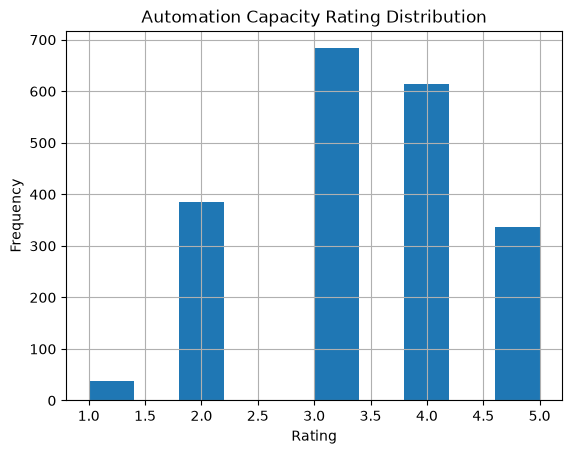

In [33]:
expert["Automation Capacity Rating"].hist()

plt.title("Automation Capacity Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

#### Biểu đồ Human Agency

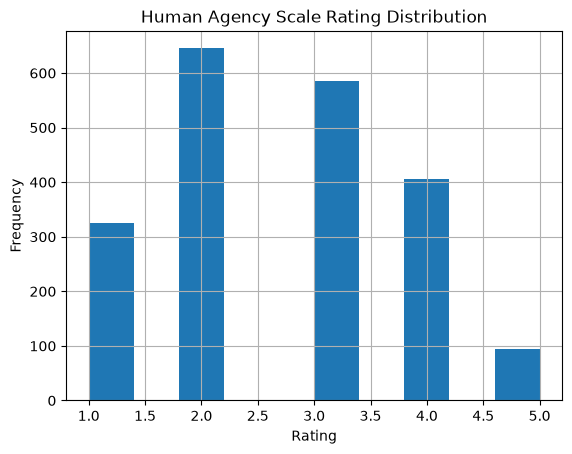

In [34]:
expert["Human Agency Scale Rating"].hist()

plt.title("Human Agency Scale Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

#### Tương quan

In [35]:
expert[
    [
        "Automation Capacity Rating",
        "Human Agency Scale Rating"
    ]
].corr()

,Automation Capacity Rating,Human Agency Scale Rating
Automation Capacity Rating,1.000000,-0.779899
Human Agency Scale Rating,-0.779899,1.000000


- Automation Capacity Rating tập trung ở mức trung bình đến cao.
- Human Agency Scale Rating tập trung ở mức thấp đến trung bình.
- Hai biến có tương quan âm mạnh (-0.78).
- Những công việc cần nhiều sự tham gia của con người thường khó tự động hóa hơn.

# AI Agent Recommendation Logic

In [36]:
expert.columns.tolist()

['Task ID',
 'Occupation (O*NET-SOC Title)',
 'Task',
 'User ID',
 'Date',
 'Automation Capacity Rating',
 'Physical Action Requirement',
 'Involved Uncertainty',
 'Domain Expertise Requirement',
 'Interpersonal Communication Requirement',
 'Human Agency Scale Rating']

## Xây dựng quy tắc khuyến nghị

#### Tạo hàm khuyến nghị

In [37]:
def recommend_ai(score):

    if score >= 4:
        return "Nên tự động hóa bằng AI Agent"

    elif score >= 3:
        return "AI Agent hỗ trợ con người"

    else:
        return "Cần con người thực hiện"

#### Tạo cột Recommendation:

In [38]:
expert["Recommendation"] = expert[
    "Automation Capacity Rating"
].apply(recommend_ai)

In [39]:
expert[
    [
        "Task",
        "Automation Capacity Rating",
        "Recommendation"
    ]
].head(10)

,Task,Automation Capacity Rating,Recommendation
0,"Inspect layouts and advertising copy, and edit...",4,Nên tự động hóa bằng AI Agent
1,Verify legal descriptions of properties by com...,3,AI Agent hỗ trợ con người
2,Review published materials and recommend revis...,4,Nên tự động hóa bằng AI Agent
3,Vary language and tone of messages based on pr...,4,Nên tự động hóa bằng AI Agent
4,Present drafts and ideas to clients.,3,AI Agent hỗ trợ con người
5,"Review advertising trends, consumer surveys, a...",5,Nên tự động hóa bằng AI Agent
6,"Write articles, bulletins, sales letters, spee...",4,Nên tự động hóa bằng AI Agent
7,Conduct research and interviews to determine w...,4,Nên tự động hóa bằng AI Agent
8,Design research projects that apply valid scie...,1,Cần con người thực hiện
9,Calculate sample size requirements for clinica...,3,AI Agent hỗ trợ con người


## Nhận xét

- Khuyến nghị được xây dựng dựa trên chỉ số Automation Capacity Rating.
- Những nhiệm vụ có điểm tự động hóa cao được đề xuất ứng dụng AI Agent.
- Những nhiệm vụ có điểm thấp vẫn cần sự tham gia của con người.

In [40]:
expert["Recommendation"].value_counts()

Recommendation
Nên tự động hóa bằng AI Agent    951
AI Agent hỗ trợ con người        683
Cần con người thực hiện          423
Name: count, dtype: int64

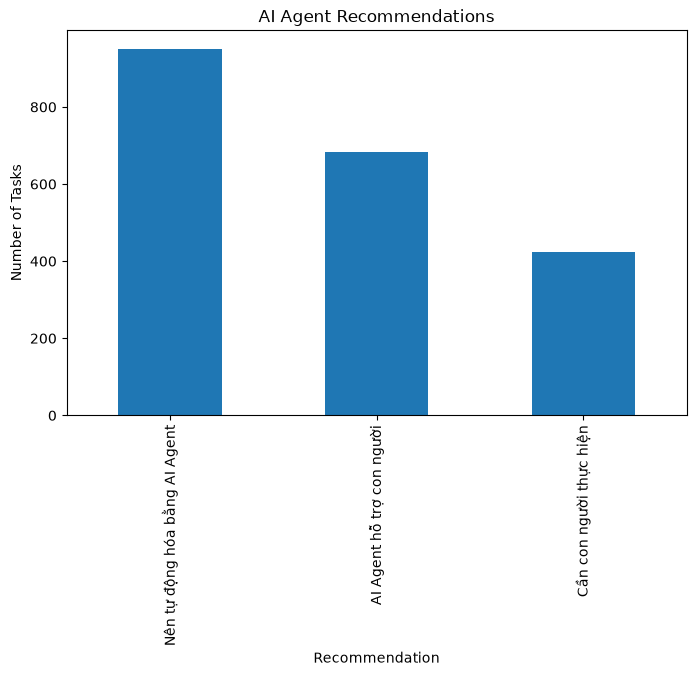

In [41]:
expert["Recommendation"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("AI Agent Recommendations")
plt.xlabel("Recommendation")
plt.ylabel("Number of Tasks")

plt.show()